<a href="https://colab.research.google.com/github/ashtonefrazier2424/ThinkPythonAssignments2026/blob/main/Week15_2/Week15_DreamProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Exit
Choose an option: 1
Title: Home Front
Author: Kristin Hannah
Genre: Historical Fiction
Pages: 390
Start date (YYYY-MM-DD): 2026-04-20
End date (YYYY-MM-DD): 2026-04-27
Rating (1-5): 5
✅ Book added!


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Exit
Choose an option: 1
Title: The Locked Door
Author: Frieda McFadden 
Genre: Thriller
Pages: 315
Start date (YYYY-MM-DD): 2026-04-15
End date (YYYY-MM-DD): 2026-04-17
Rating (1-5): 4
✅ Book added!


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Exit
Choose an option: 1
Title: The Handmaid's Tale
Author: Margsret Atwood
Genre: Sci-Fi
Pages: 310
Start date (YYYY-MM-DD): 2026-04-11
End date (YYYY-MM-DD): 2026-04-14
Rating (1-5): 5
✅ Book added!


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Exit
Choose an option: 1
Title: In Her Own League
Author: Liz Tomforde
Genre: Romance
Pages: 400
Start date (YYYY-MM-DD): 2026-04-06
End date (YYYY-MM-DD): 2026-04-10
Rating (1-

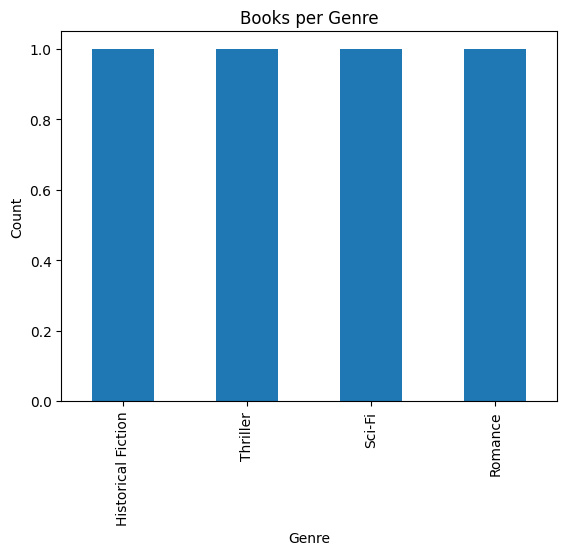


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Exit
Choose an option: 3
Goodbye!


In [2]:
# Install libraries (only needed in Colab)
!pip install pandas matplotlib

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Connect to database (creates file)
conn = sqlite3.connect("reading_tracker.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS books (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    author TEXT,
    genre TEXT,
    pages INTEGER,
    start_date TEXT,
    end_date TEXT,
    rating REAL
)
""")
conn.commit()


# -------- ADD BOOK FUNCTION --------
def add_book():
    title = input("Title: ")
    author = input("Author: ")
    genre = input("Genre: ")
    pages = int(input("Pages: "))
    start_date = input("Start date (YYYY-MM-DD): ")
    end_date = input("End date (YYYY-MM-DD): ")
    rating = float(input("Rating (1-5): "))

    cursor.execute("""
    INSERT INTO books (title, author, genre, pages, start_date, end_date, rating)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (title, author, genre, pages, start_date, end_date, rating))

    conn.commit()
    print("✅ Book added!\n")


# -------- VIEW STATS FUNCTION --------
def view_stats():
    df = pd.read_sql_query("SELECT * FROM books", conn)

    if df.empty:
        print("No data yet.")
        return

    total_pages = df["pages"].sum()
    avg_rating = df["rating"].mean()

    # Calculate reading speed
    df["start_date"] = pd.to_datetime(df["start_date"])
    df["end_date"] = pd.to_datetime(df["end_date"])
    df["days"] = (df["end_date"] - df["start_date"]).dt.days + 1
    df["speed"] = df["pages"] / df["days"]

    avg_speed = df["speed"].mean()

    print("\n📊 Reading Stats:")
    print(f"Total pages read: {total_pages}")
    print(f"Average rating: {avg_rating:.2f}")
    print(f"Average reading speed (pages/day): {avg_speed:.2f}")

    # Genre count chart
    genre_counts = df["genre"].value_counts()

    genre_counts.plot(kind='bar')
    plt.title("Books per Genre")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.show()


# -------- MAIN MENU --------
def menu():
    while True:
        print("\n--- Reading Tracker ---")
        print("1. Add Book")
        print("2. View Stats")
        print("3. Exit")

        choice = input("Choose an option: ")

        if choice == "1":
            add_book()
        elif choice == "2":
            view_stats()
        elif choice == "3":
            print("Goodbye!")
            break
        else:
            print("Invalid choice.")


menu()